a:\VisualStudioCode\VSCprojs\sbdmodel3\sbd-model-3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
Index: 55561 entries, 0 to 179724
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        55561 non-null  int64  
 1   Name              55561 non-null  str    
 2   Sex               55561 non-null  str    
 3   Event             55561 non-null  str    
 4   Equipment         55561 non-null  str    
 5   Age               55561 non-null  float64
 6   AgeClass          55561 non-null  str    
 7   BirthYearClass    51858 non-null  str    
 8   Division          55561 non-null  str    
 9   BodyweightKg      55561 non-null  float64
 10  WeightClassKg     55561 non-null  str    
 11  Squat1Kg          11573 non-null  float64
 12  Squat2Kg          11515 non-null  float64
 13  Squat3Kg          11281 non-null  float64
 14  Squat4Kg          477 non-null    float64
 15  Best3SquatKg      55561 non-null  float64
 16  Bench1Kg          11573 non-null  float64
 17  Bench2Kg

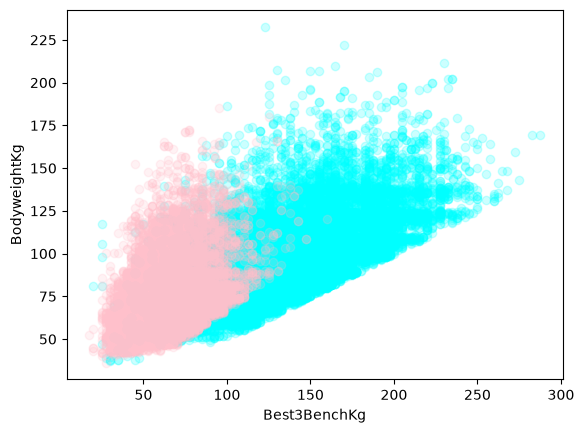

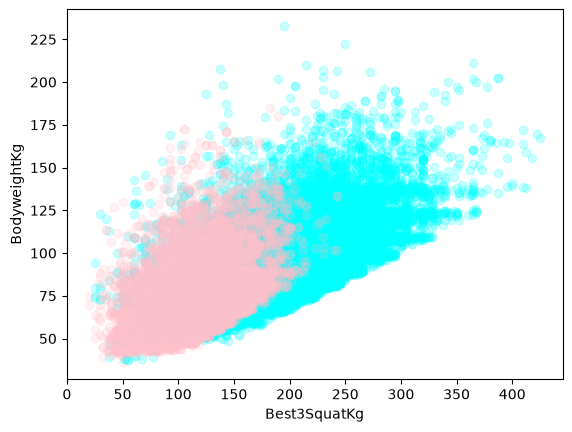

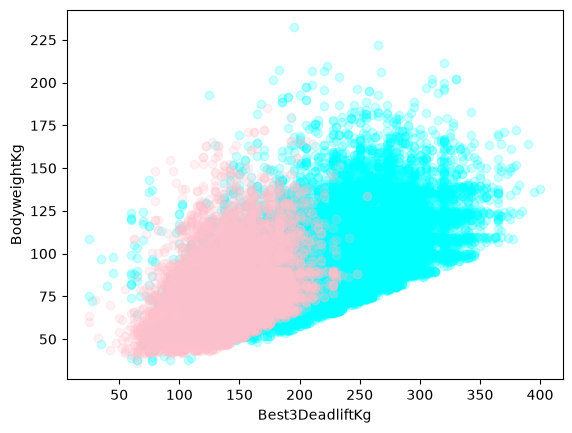

                    Name Sex  BodyweightKg  Best3SquatKg  squat_ratio   Age
43057         Brian Shim   M         75.00         225.0     3.000000  27.0
46150      Daniel SooHoo   M         67.50         202.5     3.000000  22.0
177396      Chris Joslyn   M         97.50         292.5     3.000000  34.0
163596   Isaiah Scherrer   M         74.20         222.5     2.998652  24.0
42854     Dylan Nostrant   M         80.90         242.5     2.997528  20.0
42858     Dylan Nostrant   M         80.90         242.5     2.997528  20.0
62131    James Wilson #6   M         95.95         287.5     2.996352  28.0
85075        Aaron Terry   M        109.30         327.5     2.996340  28.0
126331  Christian Pautin   M         72.60         217.5     2.995868  23.0
126450  Christian Pautin   M         72.60         217.5     2.995868  23.0
144205    Thomas Bowling   M         98.50         295.0     2.994924  20.0
144219    Thomas Bowling   M         98.50         295.0     2.994924  20.0
179158    Et

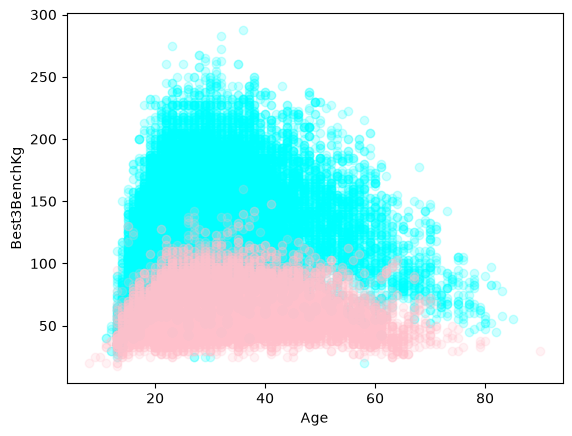

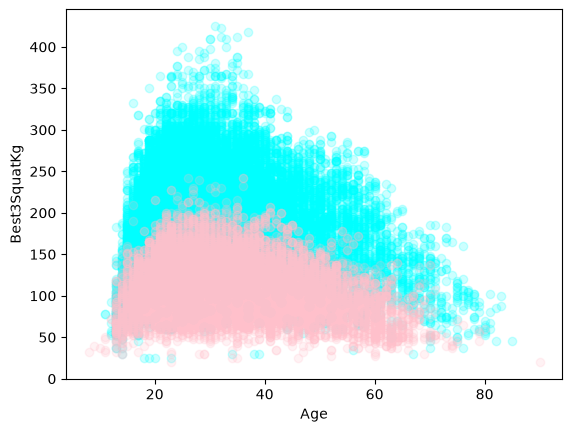

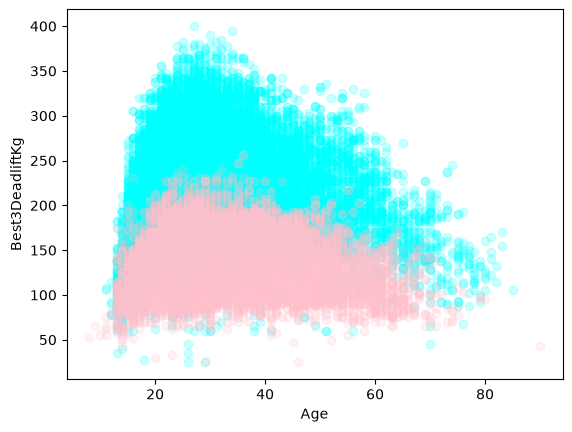

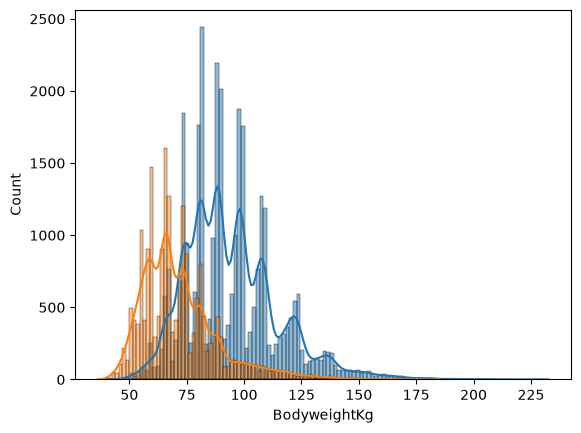

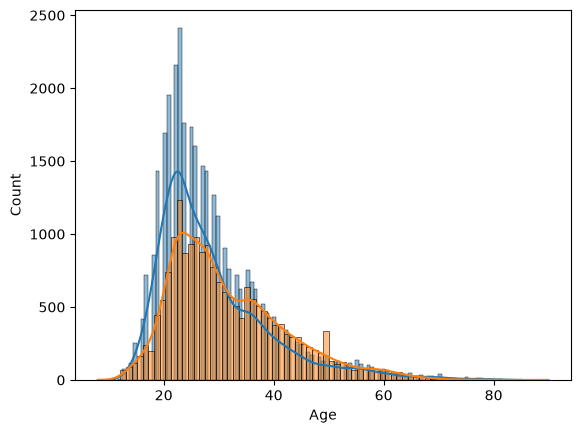

In [2]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("brianmcabee/us-powerlifting-competition-data-2015now")

raw_df = pd.read_csv(f"{path}/usa_sbd_data_2020-10-16.csv")
df = raw_df.copy()

df = df[df['Federation'] == 'USPA']
df['Place_numeric'] = pd.to_numeric(df['Place'], errors='coerce')
df = df[df['Place_numeric'].notna()]

exclusion = ['Age','BodyweightKg','Sex','Best3BenchKg','Best3SquatKg','Best3DeadliftKg']
df = df.dropna(subset=exclusion)

df['bench_ratio'] = df['Best3BenchKg'] / df['BodyweightKg']
df['squat_ratio'] = df['Best3SquatKg'] / df['BodyweightKg']
df['deadlift_ratio'] = df['Best3DeadliftKg'] / df['BodyweightKg']

df_m = df.copy()
df_m = df_m[df_m['Sex'] == 'M']
df_m = df_m[df_m['bench_ratio'] <= 2]
df_m = df_m[df_m['squat_ratio'] <= 3]
df_m = df_m[df_m['deadlift_ratio'] <= 3.5]

df_f = df.copy()
df_f = df_f[df_f['Sex'] == 'F']
df_f = df_f[df_f['bench_ratio'] <= 1.5]
df_f = df_f[df_f['squat_ratio'] <= 2.5]
df_f = df_f[df_f['deadlift_ratio'] <= 3]

df.shape
df.info()
df.isna().sum()
df.head()

# lift vs bodyweight

plt.scatter(df_m['Best3BenchKg'],df_m['BodyweightKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Best3BenchKg'],df_f['BodyweightKg'], alpha=0.2, color='pink')
plt.xlabel("Best3BenchKg")
plt.ylabel("BodyweightKg")

plt.show()

plt.scatter(df_m['Best3SquatKg'],df_m['BodyweightKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Best3SquatKg'],df_f['BodyweightKg'], alpha=0.2, color='pink')
plt.xlabel("Best3SquatKg")
plt.ylabel("BodyweightKg")

plt.show()

plt.scatter(df_m['Best3DeadliftKg'],df_m['BodyweightKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Best3DeadliftKg'],df_f['BodyweightKg'], alpha=0.2, color='pink')
plt.xlabel("Best3DeadliftKg")
plt.ylabel("BodyweightKg")

plt.show()

# data ratios

print(df_m.nlargest(30, 'squat_ratio')[['Name', 'Sex', 'BodyweightKg', 'Best3SquatKg', 'squat_ratio','Age']])
print(df_m.nlargest(30, 'bench_ratio')[['Name', 'Sex', 'BodyweightKg', 'Best3BenchKg', 'bench_ratio','Age']])
print(df_m.nlargest(30, 'deadlift_ratio')[['Name', 'Sex', 'BodyweightKg', 'Best3DeadliftKg', 'deadlift_ratio','Age']])

# age vs lift

plt.scatter(df_m['Age'],df_m['Best3BenchKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Age'],df_f['Best3BenchKg'], alpha=0.2, color='pink')
plt.xlabel("Age")
plt.ylabel("Best3BenchKg")

plt.show()

plt.scatter(df_m['Age'],df_m['Best3SquatKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Age'],df_f['Best3SquatKg'], alpha=0.2, color='pink')
plt.xlabel("Age")
plt.ylabel("Best3SquatKg")

plt.show()

plt.scatter(df_m['Age'],df_m['Best3DeadliftKg'], alpha=0.2, color='cyan')
plt.scatter(df_f['Age'],df_f['Best3DeadliftKg'], alpha=0.2, color='pink')
plt.xlabel("Age")
plt.ylabel("Best3DeadliftKg")

plt.show()

# seaborn histograms

bw_histo = sns.histplot(df_m['BodyweightKg'], kde=True)
bw_histo = sns.histplot(df_f['BodyweightKg'], kde=True)

plt.show()

age_histo = sns.histplot(df_m['Age'], kde=True)
age_histo = sns.histplot(df_f['Age'], kde=True)

#boom
    

In [3]:
print(df_m['Sex'].value_counts())
print(df_f['Sex'].value_counts())

Sex
M    32853
Name: count, dtype: int64
Sex
F    19649
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

X = df[['Age','BodyweightKg','Sex']]

y_squat = df['Best3SquatKg']
y_bench = df['Best3BenchKg']
y_deadlift = df['Best3DeadliftKg']

X_train, X_test, y_squat_train, y_squat_test = train_test_split(X, y_squat, test_size=0.2, random_state=42)
X_train, X_test, y_bench_train, y_bench_test = train_test_split(X, y_bench, test_size=0.2, random_state=42)
X_train, X_test, y_deadlift_train, y_deadlift_test = train_test_split(X, y_deadlift, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([('num', StandardScaler(), ['Age', 'BodyweightKg']), ('cat', OneHotEncoder(), ['Sex'])])

squat_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
bench_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
deadlift_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])


squat_pipeline.fit(X_train, y_squat_train)
squat_pred = squat_pipeline.predict(X_test)

bench_pipeline.fit(X_train, y_bench_train)
bench_pred = bench_pipeline.predict(X_test)

deadlift_pipeline.fit(X_train, y_deadlift_train)
deadlift_pred = deadlift_pipeline.predict(X_test)


comparison_s = pd.DataFrame({'actual': y_squat_train.values, 'predicted':squat_pipeline.predict(X_train)})
print(comparison_s.head(10))

print('test r^2 squat', r2_score(y_squat_test, squat_pred))
print('mae squat', mean_absolute_error(y_squat_test, squat_pred))
print('rmse squat', root_mean_squared_error(y_squat_test, squat_pred))

comparison_b = pd.DataFrame({'actual': y_bench_train.values, 'predicted':bench_pipeline.predict(X_train)})
print(comparison_b.head(10))

print('test r^2 bench', r2_score(y_bench_test, bench_pred))
print('mae bench', mean_absolute_error(y_bench_test, bench_pred))
print('rmse bench', root_mean_squared_error(y_bench_test, bench_pred))

comparison_d = pd.DataFrame({'actual': y_deadlift_train.values, 'predicted':deadlift_pipeline.predict(X_train)})
print(comparison_d.head(10))

print('test r^2 deadlift', r2_score(y_deadlift_test, deadlift_pred))
print('mae deadlift', mean_absolute_error(y_deadlift_test, deadlift_pred))
print('rmse deadlift', root_mean_squared_error(y_deadlift_test, deadlift_pred))



   actual   predicted
0    50.0   62.086289
1   105.0   92.588682
2    75.0   92.047314
3   222.5  207.490157
4   135.0  164.396496
5   160.0  189.787785
6   132.5  120.068145
7   175.0  169.729277
8   117.5  125.161746
9   177.5  181.506358
test r^2 squat 0.6530716866496848
mae squat 25.85998269655933
rmse squat 34.154946787662766
   actual   predicted
0    32.5   41.648530
1    55.0   47.249524
2    60.0   50.756079
3   147.5  141.502047
4    82.5  111.855507
5   110.0  128.707915
6    62.5   65.132318
7   120.0  121.674886
8    67.5   70.140349
9   125.0  122.697695
test r^2 bench 0.7230737617192803
mae bench 17.929935885111988
rmse bench 23.69116947365105
   actual   predicted
0    82.5   98.554760
1   145.0  121.356459
2   117.5  121.341366
3   277.5  238.102037
4   167.5  203.539728
5   172.5  223.837725
6   167.5  143.285344
7   205.0  208.481304
8   142.5  147.533034
9   177.5  217.161977
test r^2 deadlift 0.6697336932608291
mae deadlift 26.279363541987124
rmse deadlift 34.2951

In [ ]:
import numpy as np

df['log_BodyweightKg'] = np.log(df['BodyweightKg'])
df['sqrt_BodyweightKg'] = np.sqrt(df['BodyweightKg'])
df['Age_sq'] = df['Age'] ** 2
df['Age_cubed'] = df['Age'] ** 3
df['Age_x_Bodyweight'] = df['Age'] * df['BodyweightKg']

experiments = {
    'baseline': ['Age', 'BodyweightKg', 'Sex'],
    'log_bodyweight': ['Age', 'BodyweightKg', 'Sex', 'log_BodyweightKg'],
    'sqrt_bodyweight': ['Age', 'BodyweightKg', 'Sex', 'sqrt_BodyweightKg'],
    'age_squared': ['Age', 'BodyweightKg', 'Sex', 'Age_sq'],
    'log_and_age_sq': ['Age', 'BodyweightKg', 'Sex', 'log_BodyweightKg', 'Age_sq'],
    'sqrt_bodyweight_and_age_sq': ['Age', 'BodyweightKg', 'Sex', 'sqrt_BodyweightKg', 'Age_sq'],
}

targets = {
    'Squat': 'Best3SquatKg',
    'Bench': 'Best3BenchKg',
    'Deadlift': 'Best3DeadliftKg',
}

results = []

for exp_name, features in experiments.items():
    numeric_features = [f for f in features if f != 'Sex']
    X = df[features]

    for lift, target_col in targets.items():
        y = df[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        preprocessor = ColumnTransformer([
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(), ['Sex']),
        ])

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', GradientBoostingRegressor()),
        ])

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)

        results.append({'experiment': exp_name, 'lift': lift,
                         'r2': r2, 'mae': mae, 'rmse': rmse})

results_df = pd.DataFrame(results)
print(results_df)


                    experiment      lift        r2        mae       rmse
0                     baseline     Squat  0.706844  23.912976  31.396656
1                     baseline     Bench  0.773165  16.167873  21.441710
2                     baseline  Deadlift  0.726962  24.006999  31.182567
3               log_bodyweight     Squat  0.706967  23.906828  31.390035
4               log_bodyweight     Bench  0.773212  16.165623  21.439479
5               log_bodyweight  Deadlift  0.726998  24.005294  31.180554
6              sqrt_bodyweight     Squat  0.706981  23.907483  31.389307
7              sqrt_bodyweight     Bench  0.773208  16.165172  21.439690
8              sqrt_bodyweight  Deadlift  0.726996  24.005557  31.180643
9                  age_squared     Squat  0.706844  23.912976  31.396656
10                 age_squared     Bench  0.773165  16.167873  21.441710
11                 age_squared  Deadlift  0.726962  24.006999  31.182567
12              log_and_age_sq     Squat  0.706982 